In [1]:
from pathlib import Path
import shutil

import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from synthetic_population_qc.context_tables import (
    DA_TABLE_SPECS,
    parse_da_census_metadata,
    resolve_da_census_root,
)
from synthetic_population_qc.seed_preparation import (
    load_census_hierarchical_pumf,
    load_census_individual_pumf,
)
from synthetic_population_qc.utils import norm_code
from synthetic_population_qc.workflow_inputs import (
    build_workflow_input_contract,
    summarize_workflow_input_contract,
)


In [2]:
# Source data roots
source_repo_root = Path("../urban-energy-data")
source_data_root = source_repo_root
source_pumf_root = source_repo_root / "data" / "raw" / "PUMF"
source_chs_root = None  # Set to a Path(...) only when CHS files are available.
source_geom_path = source_repo_root / "data" / "raw" / "geometry" / "lda_000b21a_e" / "lda_000b21a_e.shp"

# Target sample raw tree inside this repo
sample_data_root = Path("data")
sample_raw_root = sample_data_root / "raw"
sample_census_root = sample_raw_root / "census" / "DA scale"
sample_pumf_root = sample_raw_root / "PUMF"
sample_pumf_ind_root = sample_pumf_root / "ind"
sample_pumf_heir_root = sample_pumf_root / "heir"
sample_chs_root = sample_raw_root / "CHS"

province = "24"  # Quebec

da_codes = [
    24661817, 24661829, 24661830, 24661831, 24661832,
    24661833, 24661835, 24661836, 24661837, 24661838,
    24661839, 24661840, 24661895, 24661896, 24661897,
    24661898, 24661899, 24661900, 24661901, 24661902,
    24661903, 24661904, 24661905, 24661906, 24661907,
    24661908, 24661909, 24661910, 24661912, 24661913,
]
da_codes_norm = [norm_code(code) for code in da_codes]

print("source_repo_root:", source_repo_root)
print("source_pumf_root:", source_pumf_root)
print("sample_raw_root:", sample_raw_root)
print("source_geom_path:", source_geom_path)
print("n_das:", len(da_codes_norm))


source_repo_root: ..\urban-energy-data
source_pumf_root: ..\urban-energy-data\data\raw\PUMF
sample_raw_root: data\raw
source_geom_path: ..\urban-energy-data\data\raw\geometry\lda_000b21a_e\lda_000b21a_e.shp
n_das: 30


In [3]:
# Inspect what the package sees in the source data
contract = build_workflow_input_contract(
    data_root=source_data_root,
    census_pumf_root=source_pumf_root,
    housing_survey_root=source_chs_root,
)

print(contract)
display(
    summarize_workflow_input_contract(
        data_root=source_data_root,
        census_pumf_root=source_pumf_root,
        housing_survey_root=source_chs_root,
    )
)


WorkflowInputContract(data_root=WindowsPath('../urban-energy-data'), census_pumf_root=WindowsPath('../urban-energy-data/data/raw/PUMF'), housing_survey_root=None, individual_pumf_candidates=(WindowsPath('../urban-energy-data/data/raw/PUMF/ind/data_donnees_2021_ind_v2.csv'), WindowsPath('../urban-energy-data/data/raw/PUMF/ind/data_donnees_2021_ind.dat'), WindowsPath('../urban-energy-data/data/raw/PUMF/ind/English/SAS, SPSS and STATA command files/ipumf_2021_final_en.dct')), household_pumf_candidates=(WindowsPath('../urban-energy-data/data/raw/PUMF/heir/data_donnees_2021_hier_v2.csv'), WindowsPath('../urban-energy-data/data/raw/PUMF/heir/data_donnees_2021_hier_v2.dat'), WindowsPath('../urban-energy-data/data/raw/PUMF/heir/English/SAS, SPSS and STATA command files/pumf2021_hierarchical_stata.dct')), housing_survey_candidates=(), available_census_tables=('age_sex_core', 'commute', 'dwelling_characteristics', 'education_detailed', 'household_type_size_detailed', 'housing', 'immigration_citi

,artifact_type,artifact_name,required,found,details
0,individual_pumf,person_seed_microdata,True,True,..\urban-energy-data\data\raw\PUMF\ind\data_do...
1,household_pumf,household_seed_microdata,True,True,..\urban-energy-data\data\raw\PUMF\heir\data_d...
2,housing_survey,chs_household_housing_seed,False,False,None
3,da_census_table,age_sex_core,True,True,..\urban-energy-data\data\raw\census\DA scale\...
4,da_census_table,education_detailed,True,True,..\urban-energy-data\data\raw\census\DA scale\...
5,da_census_table,labour_detailed,True,True,..\urban-energy-data\data\raw\census\DA scale\...
6,da_census_table,income_detailed,True,True,..\urban-energy-data\data\raw\census\DA scale\...
7,da_census_table,household_type_size_detailed,True,True,..\urban-energy-data\data\raw\census\DA scale\...
8,da_census_table,dwelling_characteristics,True,True,..\urban-energy-data\data\raw\census\DA scale\...
9,da_census_table,housing,True,True,..\urban-energy-data\data\raw\census\DA scale\...


In [4]:
# Load DA geometry and normalize the DA identifier once
if not source_geom_path.exists():
    raise FileNotFoundError(source_geom_path)

gdf = gpd.read_file(source_geom_path)
if "DAUID" not in gdf.columns:
    raise ValueError(f"Expected DAUID column. Columns are: {list(gdf.columns)}")

gdf["da_code"] = gdf["DAUID"].map(norm_code)

print(gdf.columns.tolist())
display(gdf[["DAUID", "da_code"]].head(3))


['DAUID', 'DGUID', 'LANDAREA', 'PRUID', 'geometry', 'da_code']


,DAUID,da_code
0,10010165,10010165
1,10010166,10010166
2,10010167,10010167


Selected DA polygons: 30
Requested DAs: 30
Missing DAs: [] 


,da_code
13469,24661817
13481,24661829
13482,24661830
13483,24661831
13484,24661832


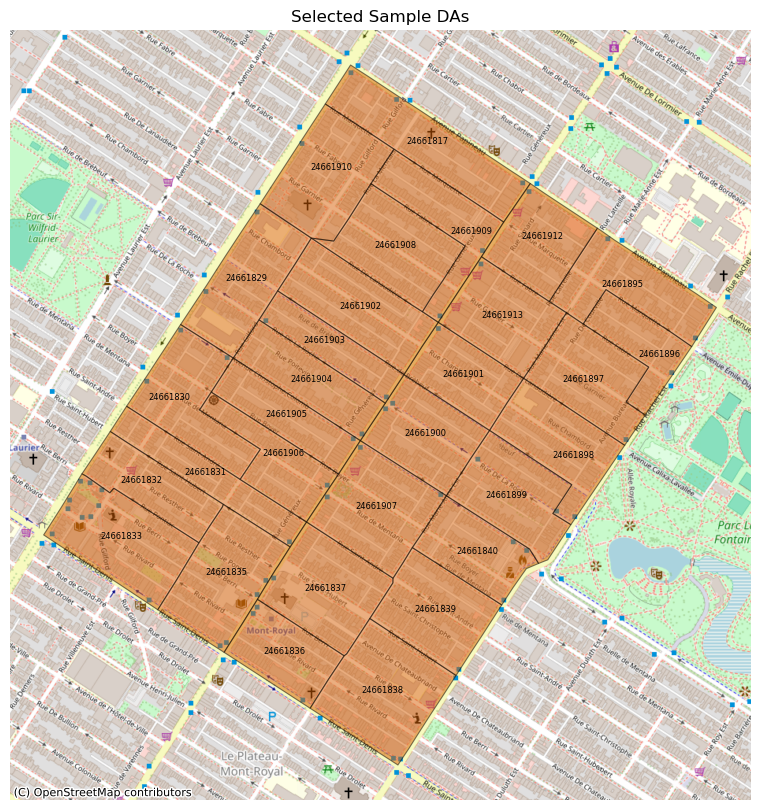

In [5]:
# Filter the selected DAs and plot them
sample_gdf = gdf.loc[gdf["da_code"].isin(da_codes_norm)].copy()

missing = sorted(set(da_codes_norm) - set(sample_gdf["da_code"]))
print("Selected DA polygons:", len(sample_gdf))
print("Requested DAs:", len(da_codes_norm))
print("Missing DAs:", missing[:10], "..." if len(missing) > 10 else "")
display(sample_gdf[["da_code"]].head())

if sample_gdf.empty:
    raise ValueError("No DA polygons matched. Check da_codes_norm against gdf['da_code'].")

sample_web = sample_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))
sample_web.plot(
    ax=ax,
    color="#d95f02",
    edgecolor="black",
    linewidth=0.8,
    alpha=0.5,
)

for _, row in sample_web.iterrows():
    pt = row.geometry.representative_point()
    ax.text(pt.x, pt.y, row["da_code"], fontsize=6, ha="center", color="black")

cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)
ax.set_title("Selected Sample DAs")
ax.set_axis_off()
plt.show()


In [6]:
# Reproject once for the main and inset maps
all_web = gdf.to_crs(epsg=3857)
sample_web = sample_gdf.to_crs(epsg=3857)


In [7]:
# Main extent
xmin, ymin, xmax, ymax = sample_web.total_bounds
pad_x = (xmax - xmin) * 0.35
pad_y = (ymax - ymin) * 0.35

main_xmin, main_xmax = xmin - pad_x, xmax + pad_x
main_ymin, main_ymax = ymin - pad_y, ymax + pad_y


In [8]:
# Zoomed-out context extent around the selected sample
mtl_pad_x = (xmax - xmin) * 10.0
mtl_pad_y = (ymax - ymin) * 10.0
mtl_xmin, mtl_xmax = xmin - mtl_pad_x, xmax + mtl_pad_x
mtl_ymin, mtl_ymax = ymin - mtl_pad_y, ymax + mtl_pad_y


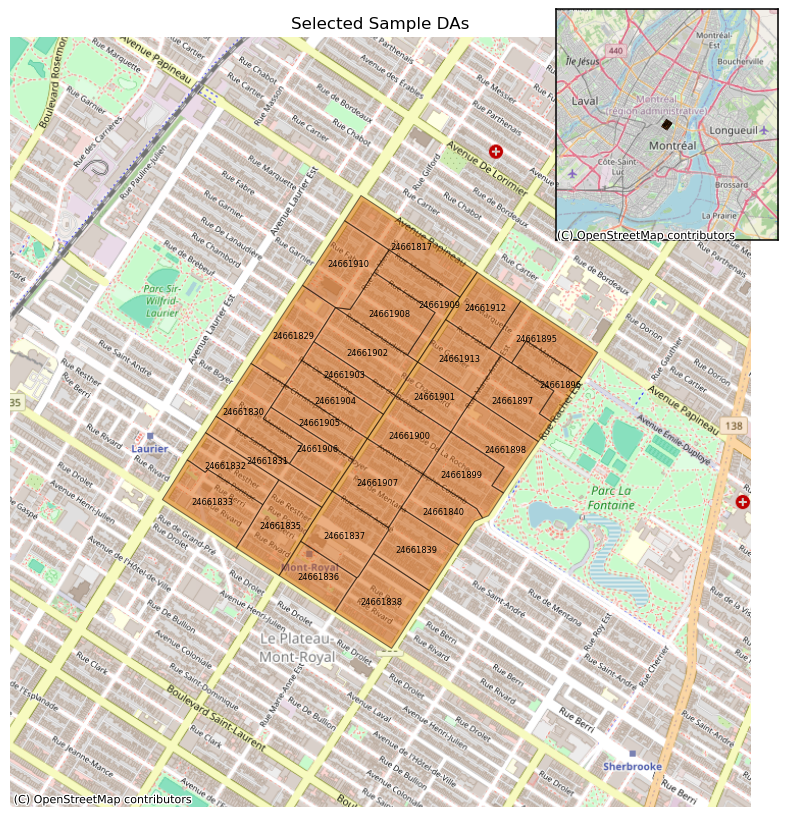

In [9]:
fig, ax = plt.subplots(figsize=(10, 10))

# Main map
sample_web.plot(
    ax=ax,
    color="#d95f02",
    edgecolor="black",
    linewidth=0.8,
    alpha=0.5,
    zorder=3,
)

for _, row in sample_web.iterrows():
    pt = row.geometry.representative_point()
    ax.text(
        pt.x,
        pt.y,
        row["da_code"],
        fontsize=6,
        ha="center",
        va="center",
        color="black",
        zorder=4,
    )

ax.set_xlim(main_xmin, main_xmax)
ax.set_ylim(main_ymin, main_ymax)

cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, zoom=15)
ax.set_title("Selected Sample DAs")
ax.set_axis_off()

# Zoomed-out inset
ax_mtl = inset_axes(
    ax,
    width="30%",
    height="30%",
    loc="upper right",
    borderpad=-2,
)

all_web.boundary.plot(
    ax=ax_mtl,
    color="gray",
    linewidth=0.15,
    alpha=0.25,
    zorder=2,
)

sample_web.plot(
    ax=ax_mtl,
    color="#d95f02",
    edgecolor="black",
    linewidth=0.5,
    alpha=0.8,
    zorder=3,
)

ax_mtl.set_xlim(mtl_xmin, mtl_xmax)
ax_mtl.set_ylim(mtl_ymin, mtl_ymax)

cx.add_basemap(ax_mtl, source=cx.providers.OpenStreetMap.Mapnik, zoom=10)
ax_mtl.set_xticks([])
ax_mtl.set_yticks([])
for spine in ax_mtl.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.1)
    spine.set_edgecolor("black")

plt.show()


In [10]:
# Create target folder structure
sample_census_root.mkdir(parents=True, exist_ok=True)
sample_pumf_ind_root.mkdir(parents=True, exist_ok=True)
sample_pumf_heir_root.mkdir(parents=True, exist_ok=True)
if source_chs_root is not None:
    sample_chs_root.mkdir(parents=True, exist_ok=True)

da_file = sample_raw_root / "sample_da_codes.txt"
da_file.write_text("\n".join(da_codes_norm), encoding="utf-8")

print("Created:")
print("  census:", sample_census_root.resolve())
print("  PUMF ind:", sample_pumf_ind_root.resolve())
print("  PUMF heir:", sample_pumf_heir_root.resolve())
if source_chs_root is not None:
    print("  CHS:", sample_chs_root.resolve())
print("  DA list:", da_file.resolve())


Created:
  census: C:\Users\m_hamsai\OneDrive - Concordia University - Canada\PhD Research\Codes and Projects\synthetic-population-qc\data\raw\census\DA scale
  PUMF ind: C:\Users\m_hamsai\OneDrive - Concordia University - Canada\PhD Research\Codes and Projects\synthetic-population-qc\data\raw\PUMF\ind
  PUMF heir: C:\Users\m_hamsai\OneDrive - Concordia University - Canada\PhD Research\Codes and Projects\synthetic-population-qc\data\raw\PUMF\heir
  DA list: C:\Users\m_hamsai\OneDrive - Concordia University - Canada\PhD Research\Codes and Projects\synthetic-population-qc\data\raw\sample_da_codes.txt


In [11]:
def read_csv_fallback(path: Path) -> pd.DataFrame:
    for encoding in ("utf-8", "cp1252", "latin1"):
        try:
            return pd.read_csv(path, encoding=encoding)
        except UnicodeDecodeError:
            pass
    return pd.read_csv(path)


def resolve_source_csv(folder: Path, expected_name: str) -> Path:
    expected = folder / expected_name
    if expected.exists():
        return expected
    candidates = sorted(folder.glob("*_data.csv"))
    if not candidates:
        raise FileNotFoundError(f"No data CSV found in {folder}")
    return candidates[0]


In [12]:
# Filter raw census DA tables and write them back in the exact folder/file shape the package expects
source_census_root = resolve_da_census_root(source_data_root)

census_manifest = []

for table_name, (subdir, expected_csv_name, metadata_name) in DA_TABLE_SPECS.items():
    src_dir = source_census_root / subdir
    src_csv = resolve_source_csv(src_dir, expected_csv_name)
    src_meta = src_dir / metadata_name

    raw_df = read_csv_fallback(src_csv)
    rename_map = parse_da_census_metadata(src_meta)

    geo_raw_col = next(
        (raw_col for raw_col, label in rename_map.items() if label.startswith("GEO UID")),
        None,
    )
    if geo_raw_col is None:
        raise KeyError(f"Could not find GEO UID column in metadata for {table_name}")

    subset = raw_df.loc[
        raw_df[geo_raw_col].map(norm_code).isin(da_codes_norm)
    ].copy()

    dst_dir = sample_census_root / subdir
    dst_dir.mkdir(parents=True, exist_ok=True)

    dst_csv = dst_dir / src_csv.name
    dst_meta = dst_dir / src_meta.name

    subset.to_csv(dst_csv, index=False)
    shutil.copy2(src_meta, dst_meta)

    census_manifest.append({
        "table": table_name,
        "rows_written": len(subset),
        "csv": str(dst_csv),
        "metadata": str(dst_meta),
    })

census_manifest = pd.DataFrame(census_manifest).sort_values("table")
display(census_manifest)

if (census_manifest["rows_written"] == 0).any():
    raise ValueError("One or more filtered census extracts are empty. Check DA normalization.")


,table,rows_written,csv,metadata
0,age_sex_core,30,"data\raw\census\DA scale\age, sex\fMyRmd2RDbkD...","data\raw\census\DA scale\age, sex\New Text Doc..."
3,commute,30,data\raw\census\DA scale\commute\ASmEBfq1h9pC_...,data\raw\census\DA scale\commute\New Text Docu...
1,dwelling_characteristics,30,data\raw\census\DA scale\dwelling char\V818MNI...,data\raw\census\DA scale\dwelling char\New Tex...
6,education_detailed,30,data\raw\census\DA scale\education\udDo1DFAvI_...,data\raw\census\DA scale\education\New Text Do...
8,household_type_size_detailed,30,"data\raw\census\DA scale\hh type, size\sl5brrk...","data\raw\census\DA scale\hh type, size\New Tex..."
2,housing,30,data\raw\census\DA scale\housing\GxvbVaVRu_dat...,data\raw\census\DA scale\housing\New Text Docu...
4,immigration_citizenship,30,"data\raw\census\DA scale\imm, citiz\iilmxSwOn_...","data\raw\census\DA scale\imm, citiz\New Text D..."
5,income_detailed,30,data\raw\census\DA scale\income\tEVGMRS0SSexK_...,data\raw\census\DA scale\income\New Text Docum...
7,labour_detailed,30,data\raw\census\DA scale\labour\EVtduVuRucOlsL...,data\raw\census\DA scale\labour\New Text Docum...


In [13]:
# Set the exact source PUMF files the workflow should use
individual_csv = source_pumf_root / "ind" / "data_donnees_2021_ind_v2.csv"
household_csv = source_pumf_root / "heir" / "data_donnees_2021_hier_v2.csv"

if not individual_csv.exists():
    raise FileNotFoundError(f"Missing individual PUMF: {individual_csv}")
if not household_csv.exists():
    raise FileNotFoundError(f"Missing household/hierarchical PUMF: {household_csv}")

print("Individual PUMF:", individual_csv)
print("Household PUMF:", household_csv)


Individual PUMF: ..\urban-energy-data\data\raw\PUMF\ind\data_donnees_2021_ind_v2.csv
Household PUMF: ..\urban-energy-data\data\raw\PUMF\heir\data_donnees_2021_hier_v2.csv


In [14]:
# Save Quebec-only versions under data/raw/PUMF/ind and data/raw/PUMF/heir
ind_df = load_census_individual_pumf(individual_csv, province=province)
hh_df = load_census_hierarchical_pumf(household_csv, province=province)

ind_out = sample_pumf_ind_root / "data_donnees_2021_ind_v2.csv"
hh_out = sample_pumf_heir_root / "data_donnees_2021_hier_v2.csv"

ind_df.to_csv(ind_out, index=False)
hh_df.to_csv(hh_out, index=False)

print("Wrote:", ind_out, ind_df.shape)
print("Wrote:", hh_out, hh_df.shape)


Wrote: data\raw\PUMF\ind\data_donnees_2021_ind_v2.csv (224250, 20)
Wrote: data\raw\PUMF\heir\data_donnees_2021_hier_v2.csv (82992, 22)


In [15]:
# Copy CHS raw artifacts into data/raw/CHS when a source CHS root is provided
if source_chs_root is None:
    print("No CHS source root configured; skipping CHS copy.")
else:
    sample_chs_root.mkdir(parents=True, exist_ok=True)
    chs_candidates = sorted(path for path in source_chs_root.rglob("*") if path.is_file())

    print("CHS candidates:")
    for p in chs_candidates:
        print(" ", p)

    for src in chs_candidates:
        dst = sample_chs_root / src.name
        shutil.copy2(src, dst)

    print(f"Copied {len(chs_candidates)} CHS files into {sample_chs_root}")


No CHS source root configured; skipping CHS copy.


In [16]:
# Verify the new sample raw tree is readable by the workflow
sample_housing_survey_root = sample_chs_root if source_chs_root is not None else None

sample_contract = build_workflow_input_contract(
    data_root=sample_data_root,
    census_pumf_root=sample_pumf_root,
    housing_survey_root=sample_housing_survey_root,
)

print(sample_contract)
display(
    summarize_workflow_input_contract(
        data_root=sample_data_root,
        census_pumf_root=sample_pumf_root,
        housing_survey_root=sample_housing_survey_root,
    )
)


WorkflowInputContract(data_root=WindowsPath('data'), census_pumf_root=WindowsPath('data/raw/PUMF'), housing_survey_root=None, individual_pumf_candidates=(WindowsPath('data/raw/PUMF/ind/data_donnees_2021_ind_v2.csv'), WindowsPath('data/raw/PUMF/data_donnees_2021_ind_v2.csv')), household_pumf_candidates=(WindowsPath('data/raw/PUMF/heir/data_donnees_2021_hier_v2.csv'), WindowsPath('data/raw/PUMF/data_donnees_2021_hier_v2.csv')), housing_survey_candidates=(), available_census_tables=('age_sex_core', 'commute', 'dwelling_characteristics', 'education_detailed', 'household_type_size_detailed', 'housing', 'immigration_citizenship', 'income_detailed', 'labour_detailed'))


,artifact_type,artifact_name,required,found,details
0,individual_pumf,person_seed_microdata,True,True,data\raw\PUMF\ind\data_donnees_2021_ind_v2.csv
1,household_pumf,household_seed_microdata,True,True,data\raw\PUMF\heir\data_donnees_2021_hier_v2.csv
2,housing_survey,chs_household_housing_seed,False,False,None
3,da_census_table,age_sex_core,True,True,"data\raw\census\DA scale\age, sex\fMyRmd2RDbkD..."
4,da_census_table,education_detailed,True,True,data\raw\census\DA scale\education\udDo1DFAvI_...
5,da_census_table,labour_detailed,True,True,data\raw\census\DA scale\labour\EVtduVuRucOlsL...
6,da_census_table,income_detailed,True,True,data\raw\census\DA scale\income\tEVGMRS0SSexK_...
7,da_census_table,household_type_size_detailed,True,True,"data\raw\census\DA scale\hh type, size\sl5brrk..."
8,da_census_table,dwelling_characteristics,True,True,data\raw\census\DA scale\dwelling char\V818MNI...
9,da_census_table,housing,True,True,data\raw\census\DA scale\housing\GxvbVaVRu_dat...


In [17]:
# Quick row-count check of the DA tables written into data/raw
from synthetic_population_qc.context_tables import load_context_tables

sample_tables = load_context_tables(sample_data_root)

summary = pd.DataFrame([
    {
        "table": name,
        "rows": df.shape[0],
        "cols": df.shape[1],
        "has_da_code": "da_code" in df.columns,
    }
    for name, df in sample_tables.items()
]).sort_values("table")

display(summary)


,table,rows,cols,has_da_code
0,age_sex_core,30,43,True
3,commute,30,33,True
1,dwelling_characteristics,30,12,True
6,education_detailed,30,6,True
8,household_type_size_detailed,30,14,True
2,housing,30,26,True
4,immigration_citizenship,30,12,True
5,income_detailed,30,14,True
7,labour_detailed,30,5,True


In [18]:
# Save a simple manifest for the sample raw package
manifest = {
    "sample_data_root": str(sample_data_root),
    "sample_raw_root": str(sample_raw_root),
    "sample_pumf_root": str(sample_pumf_root),
    "sample_chs_root": str(sample_chs_root) if source_chs_root is not None else None,
    "province": province,
    "da_codes_file": str(sample_raw_root / "sample_da_codes.txt"),
    "n_das": len(da_codes_norm),
}

pd.DataFrame([manifest]).to_csv(sample_raw_root / "sample_raw_manifest.csv", index=False)
print(sample_raw_root / "sample_raw_manifest.csv")


data\raw\sample_raw_manifest.csv
